# Figure 8

In [61]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
from stable_baselines3 import PPO,SAC, DDPG
import os

def run_rl_simulation_testing_outlier(scr, mue_max):

    experiment_name = "sac_evalcb"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)



    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue_max    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=scr*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

# Figure 8

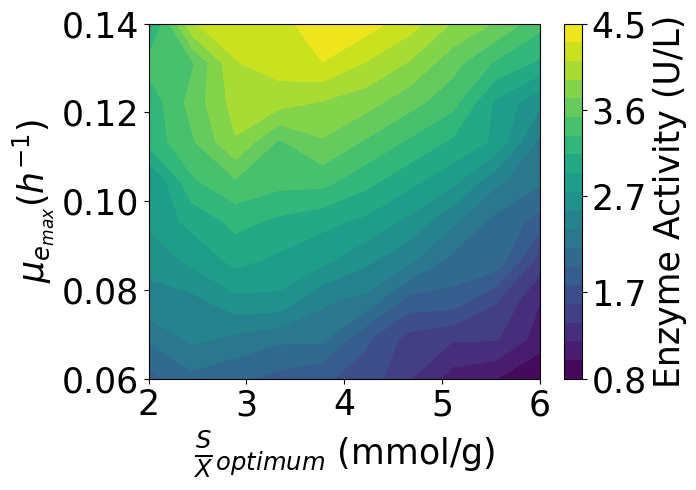

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the input data
opt_scrs = np.linspace(0.002, 0.006, 10)  # X-axis: Initial Cell Concentrations
mue_max = np.linspace(0.06, 0.14, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(opt_scrs, mue_max)

Z = np.zeros_like(X)

# Assuming run_rl_simulation_testing_outlier is defined elsewhere
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = run_rl_simulation_testing_outlier(X[i, j], Y[i, j])

# Round Z values before determining limits
Z = np.round(Z, 1)
z_min, z_max = Z.min(), Z.max()

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
contour = ax.contourf(X * 1e3, Y, Z, levels=np.linspace(z_min, z_max, 20), cmap="viridis")

# Add a colorbar with evenly spaced ticks
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label("Enzyme Activity (U/L)", fontsize=25)
cbar.ax.tick_params(labelsize=25)

# Set evenly spaced tick marks for uniform gaps
ax.set_xticks(np.linspace(opt_scrs.min() * 1e3, opt_scrs.max() * 1e3, num=5))
ax.set_yticks(np.linspace(mue_max.min(), mue_max.max(), num=5))
cbar.set_ticks(np.round(np.linspace(z_min, z_max, num=5), 1))  # Ensure rounded colorbar ticks

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

# Add plot labels and format ticks
ax.set_xlabel(r"$\frac{S}{X}_{optimum}$ (mmol/g)", fontsize=25)
ax.set_ylabel(r"$\mu_{e_{max}} (h^{-1})$", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Display the plot
plt.tight_layout()
figure_path = os.path.join('figures', 'figure8', 'figure8.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# RMSE analysis

In [63]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
from stable_baselines3 import PPO,SAC, DDPG
import os

def run_rl_simulation_testing_outlier(scr, mue_max, model_name):

    experiment_name = model_name
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)



    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue_max    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=scr*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break

    
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    ratios = (S/X)
    rmse = utils.calculate_rmse(ratios, scr)
    return rmse

# Figure 9a

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_23100\1602641784.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


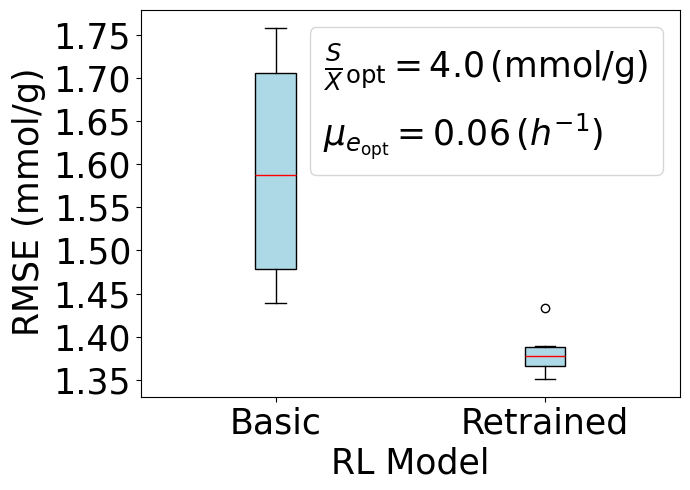

In [64]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

num_rmse_runs = 10
data1 = []
data1_basic = []
scr = 0.004
mueopt = 0.06

# Data1
for i in range(num_rmse_runs):
    data1_rmse = run_rl_simulation_testing_outlier(scr, mueopt, f'sac_rt_scr-{scr}_mopt-{mueopt}')
    data1.append(data1_rmse * 1e3)  # Scale RMSE values by 1e3
    data1_basic_rmse = run_rl_simulation_testing_outlier(scr, mueopt, 'sac_evalcb')
    data1_basic.append(data1_basic_rmse * 1e3)  # Scale RMSE values by 1e3

# Define the data
data = [data1_basic, data1]  # Ensure these are lists or 1D NumPy arrays

plt.figure(figsize=(7, 5))

# Create the box plot
plt.boxplot(
    data, 
    labels=['Basic', 'Retrained'], 
    patch_artist=True, 
    boxprops=dict(facecolor="lightblue", color="black"),  # Box color
    medianprops=dict(color="red"),                       # Median line color
    whiskerprops=dict(color="black"),                    # Whisker color
    capprops=dict(color="black")                         # Cap color
)

# Define custom legend
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\frac{{S}}{{X}}_{{\mathrm{{opt}}}} = {scr*1e3} \, (\mathrm{{mmol/g}})$'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\mu_{{e_\mathrm{{opt}}}} = {mueopt} \, (h^{{-1}})$'),
]

# Customize the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel(r'RMSE $(\mathrm{mmol/g})$', fontsize=25)  # Updated units
plt.xlabel('RL Model', fontsize=25)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Show the plot
plt.tight_layout()
plt.legend(handles=custom_lines, fontsize=25 ,handlelength=0,handletextpad=0)  # Set legend font size
figure_path = os.path.join('figures', 'figure8', 'figure8b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()


# Figure 9b

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_23100\3983869737.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


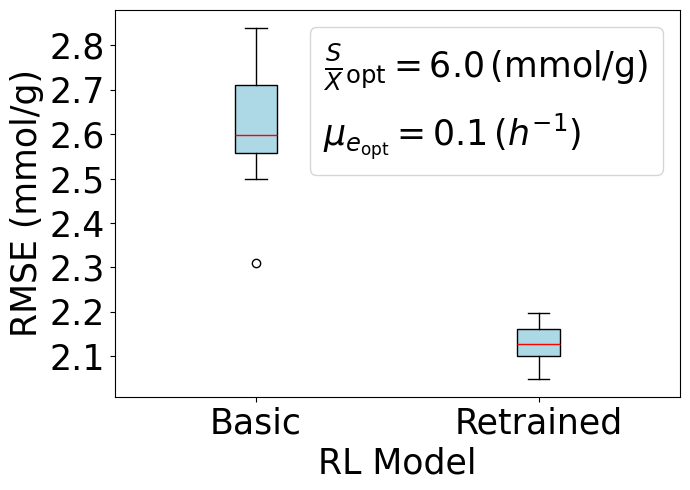

In [65]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


num_rmse_runs = 10
data1 = []
data1_basic = []
scr = 0.006
mueopt = 0.10
# Data1
for i in range(num_rmse_runs):
    data1_rmse = run_rl_simulation_testing_outlier(scr, mueopt, f'sac_rt_scr-{scr}_mopt-{mueopt}')
    data1.append(data1_rmse * 1e3)
    data1_basic_rmse = run_rl_simulation_testing_outlier(scr, mueopt, 'sac_evalcb')
    data1_basic.append(data1_basic_rmse *1e3)

# Define the data
data = [data1_basic, data1]  # Ensure these are lists or 1D NumPy arrays

plt.figure(figsize=(7, 5))

# Create the box plot
plt.boxplot(
    data, 
    labels=['Basic', 'Retrained'], 
    patch_artist=True, 
    boxprops=dict(facecolor="lightblue", color="black"),  # Box color
    medianprops=dict(color="red"),                       # Median line color
    whiskerprops=dict(color="black"),                    # Whisker color
    capprops=dict(color="black")                         # Cap color
)

# Corrected Define custom legend
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\frac{{S}}{{X}}_{{\mathrm{{opt}}}} = {scr*1e3} \, (\mathrm{{mmol/g}})$'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\mu_{{e_\mathrm{{opt}}}} = {mueopt} \, (h^{{-1}})$'),
]


# Customize the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('RMSE (mmol/g)', fontsize=25)
plt.xlabel('RL Model', fontsize=25)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Show the plot
plt.tight_layout()
plt.legend(handles=custom_lines, fontsize=25,handlelength=0,handletextpad=0)  # Set legend font size
figure_path = os.path.join('figures', 'figure8', 'figure8c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# Figure 9c

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_23100\3996448972.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


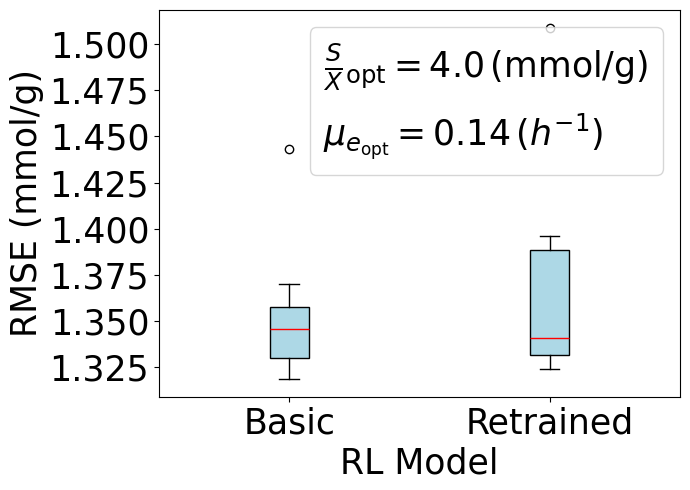

In [66]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


num_rmse_runs = 10
data1 = []
data1_basic = []
scr = 0.004
mueopt = 0.14
# Data1
for i in range(num_rmse_runs):
    data1_rmse = run_rl_simulation_testing_outlier(scr, mueopt, f'sac_rt_scr-{scr}_mopt-{mueopt}')
    data1.append(data1_rmse * 1e3)
    data1_basic_rmse = run_rl_simulation_testing_outlier(scr, mueopt, 'sac_evalcb')
    data1_basic.append(data1_basic_rmse * 1e3)

# Define the data
data = [data1_basic, data1]  # Ensure these are lists or 1D NumPy arrays

plt.figure(figsize=(7, 5))

# Create the box plot
plt.boxplot(
    data, 
    labels=['Basic', 'Retrained'], 
    patch_artist=True, 
    boxprops=dict(facecolor="lightblue", color="black"),  # Box color
    medianprops=dict(color="red"),                       # Median line color
    whiskerprops=dict(color="black"),                    # Whisker color
    capprops=dict(color="black")                         # Cap color
)

# Corrected Define custom legend
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\frac{{S}}{{X}}_{{\mathrm{{opt}}}} = {scr * 1e3} \, (\mathrm{{mmol/g}})$'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=rf'$\mu_{{e_\mathrm{{opt}}}} = {mueopt} \, (h^{{-1}})$'),
]


# Customize the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('RMSE (mmol/g)', fontsize=25)
plt.xlabel('RL Model', fontsize=25)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Show the plot
plt.tight_layout()
plt.legend(handles=custom_lines, fontsize=25, handlelength=0,handletextpad=0 )  # Set legend font size
figure_path = os.path.join('figures', 'figure8', 'figure8d.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()
